In [32]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_images(image, semantic):
    # Converter a imagem para o formato correto
    image_np = image.squeeze(0).permute(1, 2, 0).numpy().astype("uint8")

    # Converter a saída do modelo para uma imagem exibível (se necessário)
    # Usar detach() para garantir que o tensor não esteja vinculado ao gráfico de computação
    semantic_np = semantic.detach().cpu().numpy()  # Adicionado detach()
    semantic_np = semantic_np[0]  # Pegar a primeira dimensão
    semantic_np = torch.argmax(torch.tensor(semantic_np), dim=0)  # Ajuste para pegar a classe mais provável
    semantic_np = semantic_np.cpu().numpy().astype(np.uint8)

    # Criar um gráfico com 2 imagens lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(image_np)
    axes[0].set_title("Imagem Original")
    axes[0].axis("off")
    
    axes[1].imshow(semantic_np, cmap="gray")  # Ajuste o cmap conforme necessário
    axes[1].set_title("Saída do Modelo")
    axes[1].axis("off")
    print('Valores Unicos:',np.unique(semantic_np))
    print(type(semantic_np), semantic_np.shape)
    
    plt.show()
    return image_np, semantic_np


In [47]:
import numpy as np
import cv2

def save(mask, save_path):
    # Garantir que a máscara seja desconectada do gráfico de computação e convertida para NumPy
    mask = mask.detach().cpu().numpy()  # Detach do tensor e converte para numpy
    mask = mask.astype(np.uint8)  # Converte para uint8 para salvar a imagem corretamente
    
    # Se a máscara for 2D, adiciona uma dimensão extra para torná-la 3D com um único canal (para salvar com cv2)
    if mask.ndim == 2:
        mask = mask[:, :, np.newaxis]  # Adiciona um canal de profundidade para tornar (height, width) em (height, width, 1)
    
    # Salvar a imagem usando cv2
    cv2.imwrite(save_path, mask)  # Salva a imagem com o OpenCV



image.shape
torch.Size([1, 3, 600, 600])
semantic.shape
torch.Size([1, 3, 600, 600])
<class 'torch.Tensor'>
Valores Unicos: [0 1 2]
<class 'numpy.ndarray'> (600, 600)


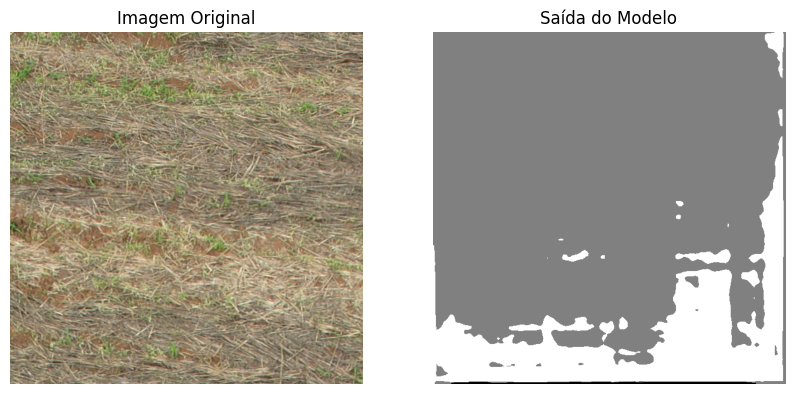

AttributeError: 'numpy.ndarray' object has no attribute 'detach'

In [48]:
from scripts.dataManipulations import Predict
import cv2

predict = Predict()
path = r'G:\My Drive\data\8_image.png'
image, semantic = predict.from_path(path)

print('image.shape')
print(image.shape)
print('semantic.shape')
print(semantic.shape)
print(type(semantic))

# Exibir as imagens
_, semantic = show_images(image, semantic)

# Salvar a segmentação
save(semantic, r'dataset\data\semantics\teste.png')

[0 1 2]


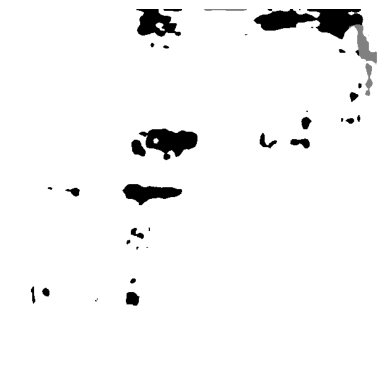

In [35]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Carregar a imagem semântica salva
image = cv2.imread(r'dataset\data\semantics\teste.png', cv2.IMREAD_GRAYSCALE)

print(np.unique(image))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

Valores Unicos: [0 1 2]
<class 'numpy.ndarray'> (600, 600)


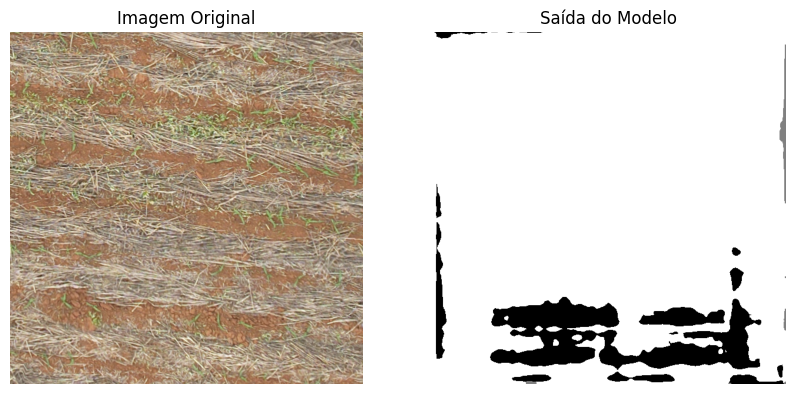

TypeError: Cannot handle this data type: (1, 1, 600), |u1

In [ ]:
import os

root = r'G:\My Drive\data'
out = r'dataset\data\semantics'

# Criar diretório de saída, se não existir
os.makedirs(out, exist_ok=True)

for image_path, image_name in [(os.path.join(root, image_name), image_name) for image_name in os.listdir(root) if image_name.endswith('png')]:
    _, semantic = predict.from_path(image_path)
    show_images(_, semantic)
    save(semantic, f'dataset\\data\\semantics\\{image_name}')  # Salvar a segmentação